# Eksplorasi Algoritma Face Recognition

Notebook ini bertujuan untuk membandingkan delapan metode pengenalan wajah:
1. **Geometry-Based (Geometric Landmarks)**
2. **PCA (Holistik)**
3. **LBP (Berbasis Fitur)**
4. **HOG (Berbasis Fitur)**
5. **LBP + PCA (Hibrida)**
6. **DeepFace - Facenet (Deep Learning)**
7. **DeepFace - VGG-Face (Deep Learning)**
8. **DeepFace - ArcFace (Deep Learning)**

Evaluasi didasarkan pada metrik Akurasi, Waktu Komputasi (Training & Inference), dan Kompleksitas Model (Penggunaan Memori Tambahan), sesuai dengan kriteria yang ditetapkan dalam TA.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
import os
import psutil
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from skimage.feature import local_binary_pattern, hog
from deepface import DeepFace
import pandas as pd

# Fungsi untuk mendapatkan penggunaan memori saat ini dalam MB
def get_memory_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

## 1. Persiapan Dataset
Menggunakan dataset publik LFW (Labeled Faces in the Wild) untuk perbandingan standar. Anda juga dapat menukar variabel data dengan dataset pribadi Anda nantinya.

In [2]:
# Variabel placeholder untuk dataset pribadi
USE_PRIVATE_DATASET = False

if not USE_PRIVATE_DATASET:
    print("Memuat dataset LFW...")
    # Menggunakan minimal 70 foto per orang untuk memastikan dataset cukup untuk klasifikasi
    lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
    
    n_samples, h, w = lfw_people.images.shape
    X = lfw_people.data
    y = lfw_people.target
    target_names = lfw_people.target_names
    n_classes = target_names.shape[0]
    
    print(f"Total dataset size:")
    print(f"n_samples: {n_samples}")
    print(f"n_features: {X.shape[1]}")
    print(f"n_classes: {n_classes}")
    
    # Split dataset 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
else:
    print("Memuat dataset pribadi...")
    # TODO: Load custom private dataset here (seperti yang dijabarkan dalam TA)
    # format outputnya diharapkan mengikuti format X_train, X_test, y_train, y_test yang sama dengan diatas
    pass

# Menyimpan metrik evaluasi
results = {
    'Model': [],
    'Accuracy': [],
    'Training Time (s)': [],
    'Inference Time (s)': [],
    'Memory Usage (MB)': []
}

Memuat dataset LFW...
Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7


## 2. Metode Berbasis Geometri: Geometry-Based Landmarks + SVM
Metode berbasis geometri mengidentifikasi wajah dengan mengukur jarak relatif antar landmark wajah utama seperti mata, hidung, dan mulut secara scale-invariant.

In [3]:
def extract_geometry_features(images, h, w):
    features = []
    for img in images:
        img_2d = img.reshape(h, w)
        h_idx, w_idx = img_2d.shape
        
        # Fungsi pembantu untuk mencari centroid daerah gelap di dalam bounding box (mata/hidung/mulut)
        def get_landmark_centroid(y_start, y_end, x_start, x_end):
            ys, ye = int(y_start * h_idx), int(y_end * h_idx)
            xs, xe = int(x_start * w_idx), int(x_end * w_idx)
            sub_img = img_2d[ys:ye, xs:xe]
            
            # Mengambil 10% piksel tergelap (warna mata/mulut biasanya lebih gelap)
            threshold = np.percentile(sub_img, 10)
            dark_pixels = np.argwhere(sub_img <= threshold)
            if len(dark_pixels) == 0:
                cy, cx = (ys + ye) / 2, (xs + xe) / 2
            else:
                cy = ys + np.mean(dark_pixels[:, 0])
                cx = xs + np.mean(dark_pixels[:, 1])
            return np.array([cx, cy])
            
        # Mengestimasikan letak landmark secara relatif pada gambar LFW yang ter-align
        left_eye = get_landmark_centroid(0.2, 0.4, 0.2, 0.45)
        right_eye = get_landmark_centroid(0.2, 0.4, 0.55, 0.8)
        nose = get_landmark_centroid(0.45, 0.7, 0.4, 0.6)
        mouth = get_landmark_centroid(0.7, 0.95, 0.3, 0.7)
        
        # Menghitung 6 jarak Euclidean berpasangan
        dists = [
            np.linalg.norm(left_eye - right_eye),
            np.linalg.norm(left_eye - nose),
            np.linalg.norm(right_eye - nose),
            np.linalg.norm(left_eye - mouth),
            np.linalg.norm(right_eye - mouth),
            np.linalg.norm(nose - mouth)
        ]
        
        # Normalisasi dengan jarak antar mata agar scale-invariant
        eye_dist = dists[0] if dists[0] > 0 else 1.0
        normalized_dists = [d / eye_dist for d in dists]
        features.append(normalized_dists)
    return np.array(features)

print("Evaluasi Geometry-Based + SVM...")
mem_before = get_memory_usage()
t0 = time.time()

X_train_geom = extract_geometry_features(X_train, h, w)
svm_geom = SVC(kernel='linear', class_weight='balanced')
svm_geom.fit(X_train_geom, y_train)

train_time = time.time() - t0
mem_after = get_memory_usage()
mem_used_geom = max(0, mem_after - mem_before)

t0 = time.time()
X_test_geom = extract_geometry_features(X_test, h, w)
y_pred_geom = svm_geom.predict(X_test_geom)
infer_time = time.time() - t0

acc_geom = accuracy_score(y_test, y_pred_geom)

results['Model'].append('Geometry-Based')
results['Accuracy'].append(acc_geom)
results['Training Time (s)'].append(train_time)
results['Inference Time (s)'].append(infer_time)
results['Memory Usage (MB)'].append(mem_used_geom)

print(f"Akurasi Geometry-Based: {acc_geom:.4f}")

Evaluasi Geometry-Based + SVM...
Akurasi Geometry-Based: 0.2481


## 3. Metode Holistik: PCA (Eigenfaces) + SVM
Principal Component Analysis (PCA) digunakan untuk mereduksi dimensi gambar sambil mempertahankan informasi penting. Algoritma Support Vector Machine (SVM) kemudian digunakan untuk klasifikasi.

In [4]:
print("Evaluasi PCA + SVM...")
mem_before = get_memory_usage()
t0 = time.time()

n_components = 150 # Jumlah principal components yang dipertahankan
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True).fit(X_train)
X_train_pca = pca.transform(X_train)

svm_pca = SVC(kernel='rbf', class_weight='balanced')
svm_pca.fit(X_train_pca, y_train)

train_time = time.time() - t0
mem_after = get_memory_usage()
mem_used_pca = max(0, mem_after - mem_before)

t0 = time.time()
X_test_pca = pca.transform(X_test)
y_pred_pca = svm_pca.predict(X_test_pca)
infer_time = time.time() - t0

acc_pca = accuracy_score(y_test, y_pred_pca)

results['Model'].append('PCA + SVM (Holistik)')
results['Accuracy'].append(acc_pca)
results['Training Time (s)'].append(train_time)
results['Inference Time (s)'].append(infer_time)
results['Memory Usage (MB)'].append(mem_used_pca)

print(f"Akurasi PCA: {acc_pca:.4f}")

Evaluasi PCA + SVM...
Akurasi PCA: 0.8527


## 4. Metode Berbasis Fitur: LBP + SVM & HOG + SVM
Metode berbasis fitur berfokus pada ekstraksi fitur lokal yang tangguh terhadap variasi pencahayaan dan ekspresi. Di sini kita membandingkan **Local Binary Pattern (LBP)** dan **Histogram of Oriented Gradients (HOG)**.

In [5]:
def extract_lbp_features(images, h, w, radius=1, n_points=8):
    features = []
    for img in images:
        img_2d = img.reshape(h, w)
        lbp = local_binary_pattern(img_2d, n_points, radius, method="uniform")
        # Fix: Lock n_bins ke n_points + 2 (10) agar dimensi selalu konsisten
        n_bins = n_points + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
        features.append(hist)
    return np.array(features)

print("Evaluasi LBP + SVM...")
mem_before = get_memory_usage()
t0 = time.time()

X_train_lbp = extract_lbp_features(X_train, h, w)
svm_lbp = SVC(kernel='linear', class_weight='balanced')
svm_lbp.fit(X_train_lbp, y_train)

train_time = time.time() - t0
mem_after = get_memory_usage()
mem_used_lbp = max(0, mem_after - mem_before)

t0 = time.time()
X_test_lbp = extract_lbp_features(X_test, h, w)
y_pred_lbp = svm_lbp.predict(X_test_lbp)
infer_time = time.time() - t0

acc_lbp = accuracy_score(y_test, y_pred_lbp)

results['Model'].append('LBP + SVM (Berbasis Fitur)')
results['Accuracy'].append(acc_lbp)
results['Training Time (s)'].append(train_time)
results['Inference Time (s)'].append(infer_time)
results['Memory Usage (MB)'].append(mem_used_lbp)

print(f"Akurasi LBP: {acc_lbp:.4f}")

print("\nEvaluasi HOG + SVM...")
def extract_hog_features(images, h, w):
    features = []
    for img in images:
        img_2d = img.reshape(h, w)
        # Ekstraksi HOG feature yang robust dan efisien
        feat = hog(img_2d, orientations=8, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), visualize=False)
        features.append(feat)
    return np.array(features)

mem_before = get_memory_usage()
t0 = time.time()

X_train_hog = extract_hog_features(X_train, h, w)
svm_hog = SVC(kernel='linear', class_weight='balanced')
svm_hog.fit(X_train_hog, y_train)

train_time = time.time() - t0
mem_after = get_memory_usage()
mem_used_hog = max(0, mem_after - mem_before)

t0 = time.time()
X_test_hog = extract_hog_features(X_test, h, w)
y_pred_hog = svm_hog.predict(X_test_hog)
infer_time = time.time() - t0

acc_hog = accuracy_score(y_test, y_pred_hog)

results['Model'].append('HOG + SVM (Berbasis Fitur)')
results['Accuracy'].append(acc_hog)
results['Training Time (s)'].append(train_time)
results['Inference Time (s)'].append(infer_time)
results['Memory Usage (MB)'].append(mem_used_hog)

print(f"Akurasi HOG: {acc_hog:.4f}")

Evaluasi LBP + SVM...
Akurasi LBP: 0.0465

Evaluasi HOG + SVM...
Akurasi HOG: 0.8682


## 5. Metode Hibrida: LBP + PCA + SVM
Menggabungkan metode berbasis fitur (LBP) dengan metode holistik (PCA). Fitur tekstur spasial diekstraksi menggunakan LBP mentah tingkat tinggi, kemudian dimensionalitasnya direduksi menggunakan PCA sebelum dimasukkan ke dalam SVM.

In [6]:
def extract_raw_lbp(images, h, w, radius=1, n_points=8):
    features = []
    for img in images:
        img_2d = img.reshape(h, w)
        lbp = local_binary_pattern(img_2d, n_points, radius, method="uniform")
        features.append(lbp.ravel())
    return np.array(features)

print("Evaluasi Hibrida LBP + PCA + SVM...")
mem_before = get_memory_usage()
t0 = time.time()

X_train_lbp_raw = extract_raw_lbp(X_train, h, w)
# Reduksi dimensi citra LBP mentah menggunakan PCA
pca_lbp = PCA(n_components=50, svd_solver='randomized', whiten=True).fit(X_train_lbp_raw)
X_train_hybrid = pca_lbp.transform(X_train_lbp_raw)

svm_hybrid = SVC(kernel='linear', class_weight='balanced')
svm_hybrid.fit(X_train_hybrid, y_train)

train_time = time.time() - t0
mem_after = get_memory_usage()
mem_used_hybrid = max(0, mem_after - mem_before)

t0 = time.time()
X_test_lbp_raw = extract_raw_lbp(X_test, h, w)
X_test_hybrid = pca_lbp.transform(X_test_lbp_raw)
y_pred_hybrid = svm_hybrid.predict(X_test_hybrid)
infer_time = time.time() - t0

acc_hybrid = accuracy_score(y_test, y_pred_hybrid)

results['Model'].append('LBP + PCA (Hibrida)')
results['Accuracy'].append(acc_hybrid)
results['Training Time (s)'].append(train_time)
results['Inference Time (s)'].append(infer_time)
results['Memory Usage (MB)'].append(mem_used_hybrid)

print(f"Akurasi Hibrida: {acc_hybrid:.4f}")

Evaluasi Hibrida LBP + PCA + SVM...
Akurasi Hibrida: 0.4612


## 6. Metode Deep Learning: Facenet (DeepFace)
Menggunakan pre-trained model Deep Learning modern **Facenet** lewat DeepFace API untuk ekstraksi representasi wajah.

In [7]:
print("Evaluasi Deep Learning (DeepFace: Facenet)...")

# Konversi grayscale ke BGR (3 channels) dengan range [0, 255] untuk DeepFace
X_train_imgs = [(img.reshape(h, w) * 255).astype(np.uint8) for img in X_train]
X_test_imgs = [(img.reshape(h, w) * 255).astype(np.uint8) for img in X_test]

def extract_deepface_embeddings(images, model_name, embedding_dim):
    embeddings = []
    print(f"  Mengekstrak embedding menggunakan model: {model_name}...")
    for idx, img in enumerate(images):
        img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        try:
            embedding_objs = DeepFace.represent(
                img_path=img_bgr, 
                model_name=model_name, 
                enforce_detection=False, 
                detector_backend="skip"
            )
            embeddings.append(embedding_objs[0]['embedding'])
        except Exception as e:
            # Fallback jika gagal ekstraksi
            embeddings.append(np.zeros(embedding_dim))
        if (idx + 1) % 100 == 0:
            print(f"    Progres: {idx + 1}/{len(images)} gambar selesai.")
    return np.array(embeddings)

print("\n--- Memulai Evaluasi Model Facenet ---")
mem_before = get_memory_usage()
t0 = time.time()

X_train_dl = extract_deepface_embeddings(X_train_imgs, "Facenet", 128)
svm_dl = SVC(kernel='linear', class_weight='balanced')
svm_dl.fit(X_train_dl, y_train)

train_time = time.time() - t0
mem_after = get_memory_usage()
mem_used_dl = max(0, mem_after - mem_before)

t0 = time.time()
X_test_dl = extract_deepface_embeddings(X_test_imgs, "Facenet", 128)
y_pred_dl = svm_dl.predict(X_test_dl)
infer_time = time.time() - t0

acc_dl = accuracy_score(y_test, y_pred_dl)

results['Model'].append('DeepFace (Facenet)')
results['Accuracy'].append(acc_dl)
results['Training Time (s)'].append(train_time)
results['Inference Time (s)'].append(infer_time)
results['Memory Usage (MB)'].append(mem_used_dl)

print(f"Akurasi Facenet: {acc_dl:.4f}")

Evaluasi Deep Learning (DeepFace: Facenet)...

--- Memulai Evaluasi Model Facenet ---
  Mengekstrak embedding menggunakan model: Facenet...
    Progres: 100/1030 gambar selesai.
    Progres: 200/1030 gambar selesai.
    Progres: 300/1030 gambar selesai.
    Progres: 400/1030 gambar selesai.
    Progres: 500/1030 gambar selesai.
    Progres: 600/1030 gambar selesai.
    Progres: 700/1030 gambar selesai.
    Progres: 800/1030 gambar selesai.
    Progres: 900/1030 gambar selesai.
    Progres: 1000/1030 gambar selesai.
  Mengekstrak embedding menggunakan model: Facenet...
    Progres: 100/258 gambar selesai.
    Progres: 200/258 gambar selesai.
Akurasi Facenet: 0.9922


## 7. Metode Deep Learning: VGG-Face (DeepFace)
Menggunakan pre-trained model Deep Learning modern **VGG-Face** lewat DeepFace API untuk ekstraksi representasi wajah.

In [8]:
print("\n--- Memulai Evaluasi Model VGG-Face ---")
mem_before = get_memory_usage()
t0 = time.time()

X_train_dl = extract_deepface_embeddings(X_train_imgs, "VGG-Face", 2622)
svm_dl = SVC(kernel='linear', class_weight='balanced')
svm_dl.fit(X_train_dl, y_train)

train_time = time.time() - t0
mem_after = get_memory_usage()
mem_used_dl = max(0, mem_after - mem_before)

t0 = time.time()
X_test_dl = extract_deepface_embeddings(X_test_imgs, "VGG-Face", 2622)
y_pred_dl = svm_dl.predict(X_test_dl)
infer_time = time.time() - t0

acc_dl = accuracy_score(y_test, y_pred_dl)

results['Model'].append('DeepFace (VGG-Face)')
results['Accuracy'].append(acc_dl)
results['Training Time (s)'].append(train_time)
results['Inference Time (s)'].append(infer_time)
results['Memory Usage (MB)'].append(mem_used_dl)

print(f"Akurasi VGG-Face: {acc_dl:.4f}")


--- Memulai Evaluasi Model VGG-Face ---
  Mengekstrak embedding menggunakan model: VGG-Face...
    Progres: 100/1030 gambar selesai.
    Progres: 200/1030 gambar selesai.
    Progres: 300/1030 gambar selesai.
    Progres: 400/1030 gambar selesai.
    Progres: 500/1030 gambar selesai.
    Progres: 600/1030 gambar selesai.
    Progres: 700/1030 gambar selesai.
    Progres: 800/1030 gambar selesai.
    Progres: 900/1030 gambar selesai.
    Progres: 1000/1030 gambar selesai.
  Mengekstrak embedding menggunakan model: VGG-Face...
    Progres: 100/258 gambar selesai.
    Progres: 200/258 gambar selesai.
Akurasi VGG-Face: 0.9961


## 8. Metode Deep Learning: ArcFace (DeepFace)
Menggunakan pre-trained model Deep Learning modern **ArcFace** lewat DeepFace API untuk ekstraksi representasi wajah.

In [10]:
print("\n--- Memulai Evaluasi Model ArcFace ---")
mem_before = get_memory_usage()
t0 = time.time()

X_train_dl = extract_deepface_embeddings(X_train_imgs, "ArcFace", 512)
svm_dl = SVC(kernel='linear', class_weight='balanced')
svm_dl.fit(X_train_dl, y_train)

train_time = time.time() - t0
mem_after = get_memory_usage()
mem_used_dl = max(0, mem_after - mem_before)

t0 = time.time()
X_test_dl = extract_deepface_embeddings(X_test_imgs, "ArcFace", 512)
y_pred_dl = svm_dl.predict(X_test_dl)
infer_time = time.time() - t0

acc_dl = accuracy_score(y_test, y_pred_dl)

results['Model'].append('DeepFace (ArcFace)')
results['Accuracy'].append(acc_dl)
results['Training Time (s)'].append(train_time)
results['Inference Time (s)'].append(infer_time)
results['Memory Usage (MB)'].append(mem_used_dl)

print(f"Akurasi ArcFace: {acc_dl:.4f}")


--- Memulai Evaluasi Model ArcFace ---
  Mengekstrak embedding menggunakan model: ArcFace...
    Progres: 100/1030 gambar selesai.
    Progres: 200/1030 gambar selesai.
    Progres: 300/1030 gambar selesai.
    Progres: 400/1030 gambar selesai.
    Progres: 500/1030 gambar selesai.
    Progres: 600/1030 gambar selesai.
    Progres: 700/1030 gambar selesai.
    Progres: 800/1030 gambar selesai.
    Progres: 900/1030 gambar selesai.
    Progres: 1000/1030 gambar selesai.
  Mengekstrak embedding menggunakan model: ArcFace...
    Progres: 100/258 gambar selesai.
    Progres: 200/258 gambar selesai.
Akurasi ArcFace: 0.9961


## 9. Visualisasi dan Perbandingan Kinerja
Menampilkan hasil komparasi kedelapan metode tersebut berdasarkan 3 kriteria utama: Akurasi, Waktu Komputasi (detik), dan Penggunaan Memori Tambahan (MB).


--- Hasil Perbandingan Lengkap (8 Model) ---
                     Model  Accuracy  Training Time (s)  Inference Time (s)  Memory Usage (MB)
            Geometry-Based  0.248062           0.359941            0.071490           0.609375
      PCA + SVM (Holistik)  0.852713           0.332632            0.038908          16.238281
LBP + SVM (Berbasis Fitur)  0.046512           0.397224            0.079943           0.054688
HOG + SVM (Berbasis Fitur)  0.868217           0.551792            0.121563           4.605469
       LBP + PCA (Hibrida)  0.461240           0.770111            0.068840          23.777344
        DeepFace (Facenet)  0.992248         226.076691           57.136261         223.914062
       DeepFace (VGG-Face)  0.996124         211.171392           53.232426        1966.363281
        DeepFace (ArcFace)  0.996124         174.232731           40.024924           5.554688


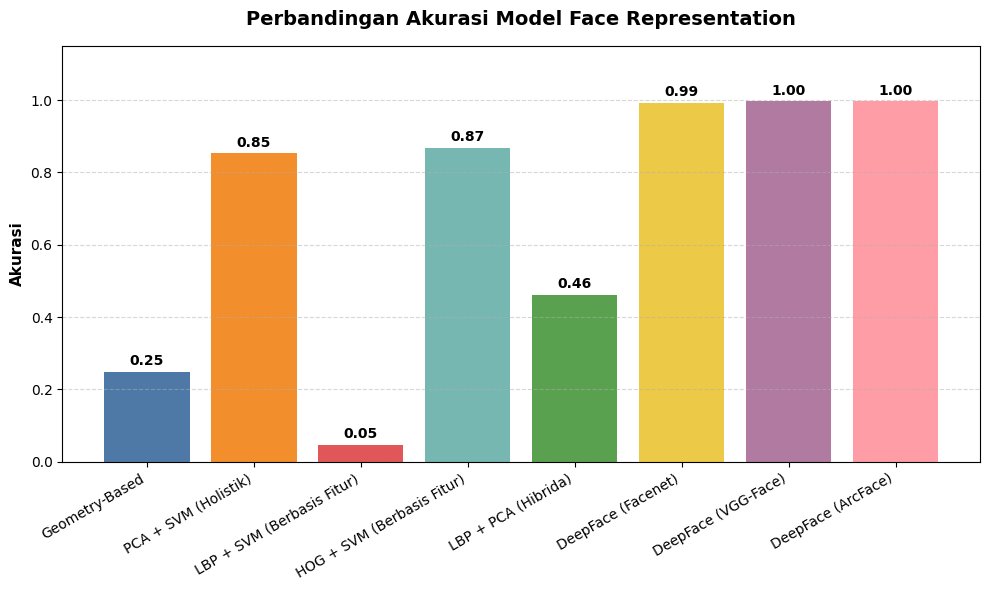

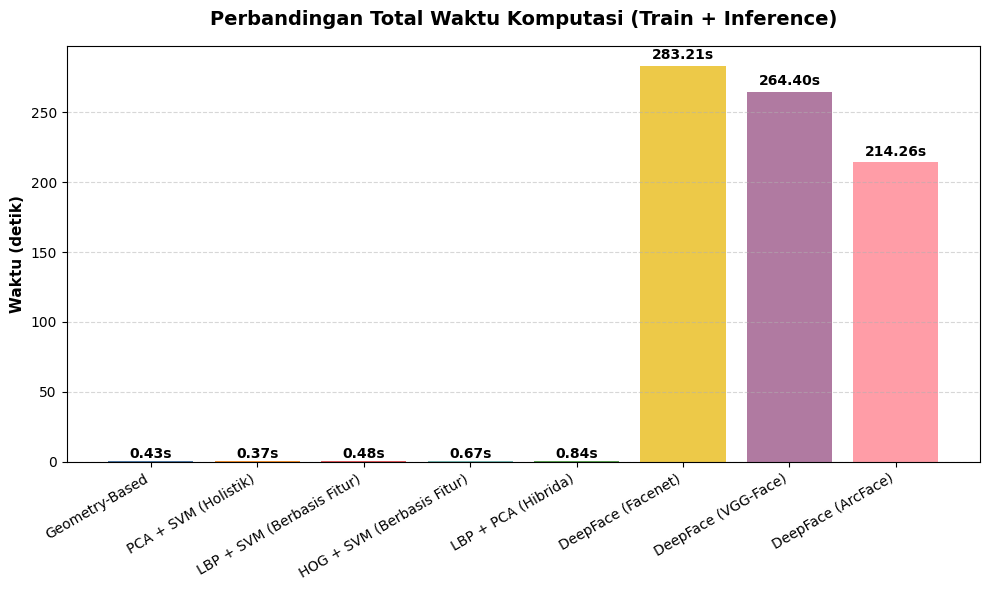

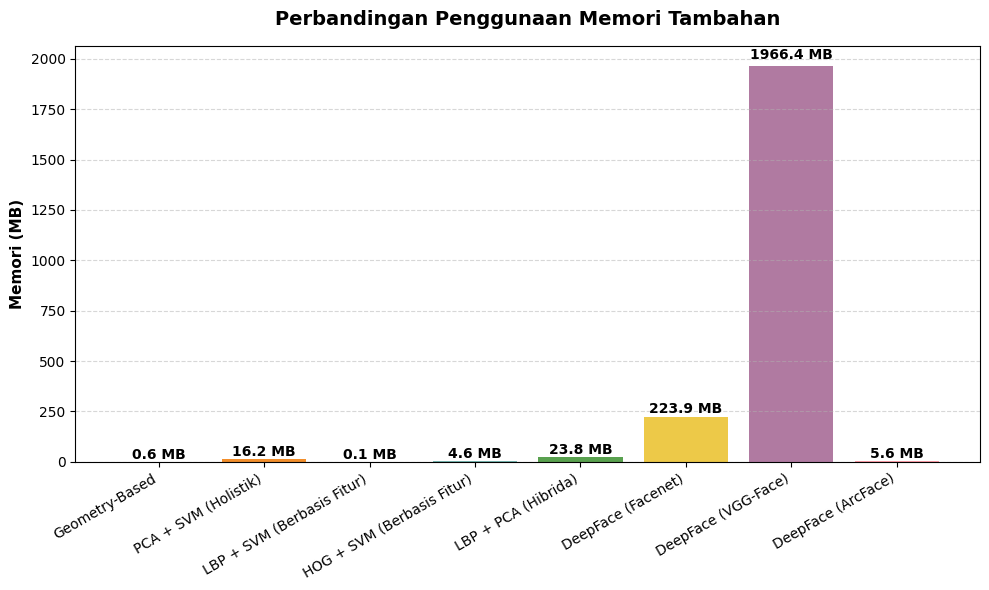

In [13]:
df_results = pd.DataFrame(results)
print("\n--- Hasil Perbandingan Lengkap (8 Model) ---")
print(df_results.to_string(index=False))

# Menggunakan palet warna Tableau 10 modern untuk visualisasi premium
colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F', '#EDC948', '#B07AA1', '#FF9DA7']

# -------------------------------------------------------------------------
# PLOT 1: AKURASI MODEL
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
bars1 = plt.bar(df_results['Model'], df_results['Accuracy'], color=colors[:len(df_results)])
plt.title('Perbandingan Akurasi Model Face Representation', fontsize=14, fontweight='bold', pad=15)
plt.ylim(0, 1.15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Akurasi', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('1_akurasi_model.png', dpi=300) # Lepas komen untuk langsung save gambar
plt.show()

# -------------------------------------------------------------------------
# PLOT 2: TOTAL WAKTU KOMPUTASI
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
total_time = df_results['Training Time (s)'] + df_results['Inference Time (s)']
bars2 = plt.bar(df_results['Model'], total_time, color=colors[:len(df_results)])
plt.title('Perbandingan Total Waktu Komputasi (Train + Inference)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Waktu (detik)', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars2:
    yval = bar.get_height()
    # Penyesuaian jarak text agar dinamis baik untuk waktu kecil maupun besar
    offset = (yval * 0.01) + 0.05
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + offset, f"{yval:.2f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('2_waktu_komputasi.png', dpi=300) # Lepas komen untuk langsung save gambar
plt.show()

# -------------------------------------------------------------------------
# PLOT 3: PENGGUNAAN MEMORI
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
bars3 = plt.bar(df_results['Model'], df_results['Memory Usage (MB)'], color=colors[:len(df_results)])
plt.title('Perbandingan Penggunaan Memori Tambahan', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Memori (MB)', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars3:
    yval = bar.get_height()
    offset = (yval * 0.01) + 0.1
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + offset, f"{yval:.1f} MB", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('3_penggunaan_memori.png', dpi=300) # Lepas komen untuk langsung save gambar
plt.show()